# Эксперимент 2 — Регрессионные модели + макроэкономические данные

**Цель:** проверить, улучшат ли макроэкономические признаки качество предсказания цен.

**Данные:** `merged_clean.csv` + макроданные из `data/macro/processed/`

**Новые признаки:** cbr_rate, inflation, usd_rate, income_mln

**Разделение:** Train 2018–2020 (стратифицированная 1.5M), Test 2021 (500k) — то же что в Эксперименте 1

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Загрузка данных о недвижимости

In [19]:
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['date'])
print('Загружено:', df.shape)

df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['date_key'] = df['date'].dt.to_period('M').astype(str)  # формат YYYY-MM для джойна

print('Колонки:', list(df.columns))

Загружено: (16815835, 13)
Колонки: ['date', 'price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'geo_lat', 'geo_lon', 'object_type', 'region', 'source', 'dist_to_center', 'year', 'month', 'date_key']


## 2. Загрузка макроданных

In [20]:
cbr    = pd.read_csv('../data/macro/processed/cbr_rate.csv')
exrate = pd.read_csv('../data/macro/processed/exchange_rate.csv')
income = pd.read_csv('../data/macro/processed/income.csv')

# cbr содержит и cbr_rate и inflation
macro_monthly = cbr.merge(exrate, on='date', how='inner')

print('macro_monthly (ставка + инфляция + курс):', macro_monthly.shape)
print(macro_monthly.head(3))
print()
print('income (по регионам):', income.shape)
print(income.head(3))

macro_monthly (ставка + инфляция + курс): (48, 4)
      date  cbr_rate  inflation  usd_rate
0  2018-01      7.75        2.2     56.50
1  2018-02      7.50        2.2     56.81
2  2018-03      7.25        2.4     57.06

income (по регионам): (4176, 3)
      date  region  income_mln
0  2018-01       1    150331.0
1  2018-01       2   1410504.0
2  2018-01       3    284595.0


## 3. Джойн макроданных к основному датасету

In [21]:
# 3.1 Джойн по дате (ставка, инфляция, курс) — без привязки к региону
df = df.merge(macro_monthly, left_on='date_key', right_on='date', how='left', suffixes=('', '_macro'))
df = df.drop(columns=['date_macro'], errors='ignore')

print('После джойна макро по дате:', df.shape)
print('NaN cbr_rate:', df['cbr_rate'].isna().sum())
print('NaN usd_rate:', df['usd_rate'].isna().sum())

После джойна макро по дате: (16815835, 19)
NaN cbr_rate: 0
NaN usd_rate: 0


In [22]:
# 3.2 Джойн доходов по дате + региону
income['region'] = income['region'].astype(int)

# Дедупликация: некоторые регионы попали дважды (разные названия → один код)
# Берём среднее на случай небольших расхождений значений
n_before = len(income)
income = income.groupby(['date', 'region'])['income_mln'].mean().reset_index()
print(f'income: {n_before} → {len(income)} строк после дедупликации')
print(f'Дублей удалено: {n_before - len(income)}')

df['region_int'] = df['region'].astype(int)

df = df.merge(
    income.rename(columns={'date': 'date_key2'}),
    left_on=['date_key', 'region_int'],
    right_on=['date_key2', 'region'],
    how='left',
    suffixes=('', '_inc')
)
df = df.drop(columns=['date_key2', 'region_inc', 'region_int'], errors='ignore')

print('После джойна доходов по дате+региону:', df.shape)
print('NaN income_mln:', df['income_mln'].isna().sum())
print()
print('Колонки финального датасета:')
print(list(df.columns))

income: 4176 → 4080 строк после дедупликации
Дублей удалено: 96
После джойна доходов по дате+региону: (16815835, 20)
NaN income_mln: 0

Колонки финального датасета:
['date', 'price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'geo_lat', 'geo_lon', 'object_type', 'region', 'source', 'dist_to_center', 'year', 'month', 'date_key', 'cbr_rate', 'inflation', 'usd_rate', 'income_mln']


## 4. Разделение данных (то же разбиение, что в Эксперименте 1)

In [23]:
train_full = df[df['year'] <= 2020].copy()
test_full  = df[df['year'] == 2021].copy()

print(f'Train (2018–2020): {len(train_full):,}')
print(f'Test  (2021):      {len(test_full):,}')

# Стратифицированная выборка train по годам (~1.5M)
TRAIN_SAMPLE = 1_500_000
year_counts = train_full['year'].value_counts()
year_fracs  = year_counts / year_counts.sum()

train_parts = []
for year, frac in year_fracs.items():
    n = int(TRAIN_SAMPLE * frac)
    part = train_full[train_full['year'] == year].sample(n, random_state=RANDOM_STATE)
    train_parts.append(part)
    print(f'  {year}: {n:,} записей')

train = pd.concat(train_parts, ignore_index=True)
test  = test_full.sample(500_000, random_state=RANDOM_STATE)

print(f'\nИтого train: {len(train):,}')
print(f'Итого test:  {len(test):,}')

Train (2018–2020): 4,902,771
Test  (2021):      11,913,064
  2019: 682,739 записей
  2020: 550,732 записей
  2018: 266,528 записей

Итого train: 1,499,999
Итого test:  500,000


## 5. Подготовка признаков

In [24]:
# Базовые признаки (те же что в Эксперименте 1) + макро
FEATURES_BASE  = ['area', 'kitchen_area', 'level', 'levels', 'rooms',
                   'object_type', 'region', 'dist_to_center',
                   'geo_lat', 'geo_lon', 'year', 'month']

FEATURES_MACRO = FEATURES_BASE + ['cbr_rate', 'inflation', 'usd_rate', 'income_mln']

TARGET = 'price'

X_train = train[FEATURES_MACRO]
y_train = train[TARGET]
X_test  = test[FEATURES_MACRO]
y_test  = test[TARGET]

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print()
print('Пропуски в train:')
missing = X_train.isnull().sum()
print(missing[missing > 0])

X_train: (1499999, 16)
X_test:  (500000, 16)

Пропуски в train:
Series([], dtype: int64)


## 6. Функция оценки моделей

In [25]:
results = {}

# Результаты Эксперимента 1 для сравнения
results_exp1 = {
    'Linear Regression': {'MAE': 3.278e6, 'RMSE': 12.094e6, 'R²': 0.1505},
    'Ridge':             {'MAE': 3.278e6, 'RMSE': 12.094e6, 'R²': 0.1505},
    'Lasso':             {'MAE': 3.278e6, 'RMSE': 12.094e6, 'R²': 0.1505},
    'Random Forest':     {'MAE': 1.854e6, 'RMSE': 6.908e6,  'R²': 0.7228},
    'XGBoost':           {'MAE': 1.814e6, 'RMSE': 7.697e6,  'R²': 0.6559},
    'LightGBM':          {'MAE': 1.825e6, 'RMSE': 7.222e6,  'R²': 0.6971},
    'CatBoost':          {'MAE': 1.913e6, 'RMSE': 7.660e6,  'R²': 0.6591},
}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = root_mean_squared_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    r2_prev = results_exp1.get(name, {}).get('R²', None)
    delta = f'  Δ R²={r2 - r2_prev:+.4f}' if r2_prev is not None else ''
    print(f'{name:30s}  MAE={mae/1e6:.3f}M  RMSE={rmse/1e6:.3f}M  R²={r2:.4f}{delta}')
    return model

## 7. Линейные модели

In [26]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

evaluate('Linear Regression', LinearRegression(),  X_train_imp, y_train, X_test_imp, y_test)
evaluate('Ridge',             Ridge(alpha=1.0),     X_train_imp, y_train, X_test_imp, y_test)
evaluate('Lasso',             Lasso(alpha=100.0),   X_train_imp, y_train, X_test_imp, y_test)

Linear Regression               MAE=2.658M  RMSE=11.519M  R²=0.2294  Δ R²=+0.0789
Ridge                           MAE=2.658M  RMSE=11.519M  R²=0.2294  Δ R²=+0.0789
Lasso                           MAE=2.659M  RMSE=11.519M  R²=0.2293  Δ R²=+0.0788


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",100.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


## 8. Random Forest

In [27]:
rf = evaluate('Random Forest',
    RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_imp, y_train, X_test_imp, y_test
)

Random Forest                   MAE=1.910M  RMSE=6.930M  R²=0.7210  Δ R²=-0.0018


## 9. XGBoost

In [28]:
xgb = evaluate('XGBoost',
    XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                 subsample=0.8, colsample_bytree=0.8,
                 n_jobs=-1, random_state=RANDOM_STATE),
    X_train_imp, y_train, X_test_imp, y_test
)

XGBoost                         MAE=1.880M  RMSE=7.842M  R²=0.6428  Δ R²=-0.0131


## 10. LightGBM

In [29]:
lgbm = evaluate('LightGBM',
    LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                  num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                  n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
    X_train, y_train, X_test, y_test
)

LightGBM                        MAE=1.887M  RMSE=7.325M  R²=0.6883  Δ R²=-0.0088


## 11. CatBoost

In [30]:
cb = evaluate('CatBoost',
    CatBoostRegressor(iterations=500, learning_rate=0.05, depth=7,
                      random_seed=RANDOM_STATE, verbose=0),
    X_train, y_train, X_test, y_test
)

CatBoost                        MAE=1.912M  RMSE=7.573M  R²=0.6669  Δ R²=+0.0078


## 12. Сравнение: Эксперимент 1 vs Эксперимент 2

In [31]:
# Таблица сравнения по всем метрикам
models = list(results.keys())
compare_rows = []
for m in models:
    r1 = results_exp1.get(m, {})
    r2 = results[m]
    compare_rows.append({
        'Модель': m,
        'MAE Эксп.1, млн':  round(r1.get('MAE',  float('nan')) / 1e6, 3),
        'MAE Эксп.2, млн':  round(r2['MAE'] / 1e6, 3),
        'ΔMAE':             round((r2['MAE'] - r1.get('MAE', r2['MAE'])) / 1e6, 3),
        'RMSE Эксп.1, млн': round(r1.get('RMSE', float('nan')) / 1e6, 3),
        'RMSE Эксп.2, млн': round(r2['RMSE'] / 1e6, 3),
        'ΔRMSE':            round((r2['RMSE'] - r1.get('RMSE', r2['RMSE'])) / 1e6, 3),
        'R² Эксп.1':        round(r1.get('R²',   float('nan')), 4),
        'R² Эксп.2':        round(r2['R²'], 4),
        'ΔR²':              round(r2['R²'] - r1.get('R²', r2['R²']), 4),
    })

compare_df = pd.DataFrame(compare_rows).sort_values('R² Эксп.2', ascending=False)
display(compare_df.set_index('Модель'))

,"MAE Эксп.1, млн","MAE Эксп.2, млн",ΔMAE,"RMSE Эксп.1, млн","RMSE Эксп.2, млн",ΔRMSE,R² Эксп.1,R² Эксп.2,ΔR²
Модель,,,,,,,,,
Random Forest,1.854,1.910,0.056,6.908,6.930,0.022,0.7228,0.7210,-0.0018
LightGBM,1.825,1.887,0.062,7.222,7.325,0.103,0.6971,0.6883,-0.0088
CatBoost,1.913,1.912,-0.001,7.660,7.573,-0.087,0.6591,0.6669,0.0078
XGBoost,1.814,1.880,0.066,7.697,7.842,0.145,0.6559,0.6428,-0.0131
Linear Regression,3.278,2.658,-0.620,12.094,11.519,-0.575,0.1505,0.2294,0.0789
Ridge,3.278,2.658,-0.620,12.094,11.519,-0.575,0.1505,0.2294,0.0789
Lasso,3.278,2.659,-0.619,12.094,11.519,-0.575,0.1505,0.2293,0.0788


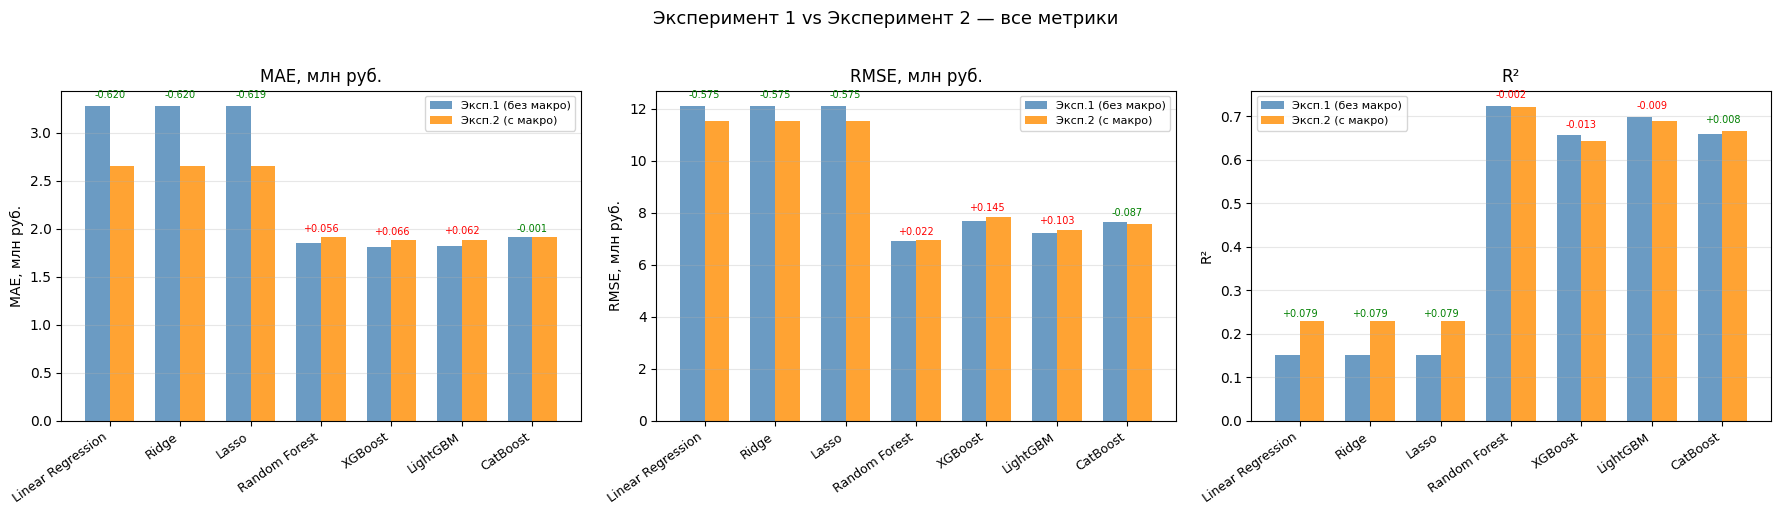

In [32]:
# Визуализация: все три метрики, Эксп.1 vs Эксп.2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(models))
width = 0.35
colors1, colors2 = 'steelblue', 'darkorange'

metrics = [
    ('MAE, млн руб.',  [results_exp1[m]['MAE']  / 1e6 for m in models], [results[m]['MAE']  / 1e6 for m in models], False),
    ('RMSE, млн руб.', [results_exp1[m]['RMSE'] / 1e6 for m in models], [results[m]['RMSE'] / 1e6 for m in models], False),
    ('R²',             [results_exp1[m]['R²']         for m in models], [results[m]['R²']         for m in models], True),
]

for ax, (ylabel, vals1, vals2, higher_better) in zip(axes, metrics):
    bars1 = ax.bar(x - width/2, vals1, width, label='Эксп.1 (без макро)', color=colors1, alpha=0.8)
    bars2 = ax.bar(x + width/2, vals2, width, label='Эксп.2 (с макро)',   color=colors2, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # Подписи Δ над каждой парой столбцов
    for i, (v1, v2) in enumerate(zip(vals1, vals2)):
        delta = v2 - v1
        sign  = '+' if delta > 0 else ''
        color = ('green' if higher_better else 'red') if delta > 0 else ('red' if higher_better else 'green')
        top   = max(v1, v2) * 1.02
        ax.text(i, top, f'{sign}{delta:.3f}', ha='center', va='bottom', fontsize=7, color=color)

plt.suptitle('Эксперимент 1 vs Эксперимент 2 — все метрики', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. SHAP — важность признаков (LightGBM)

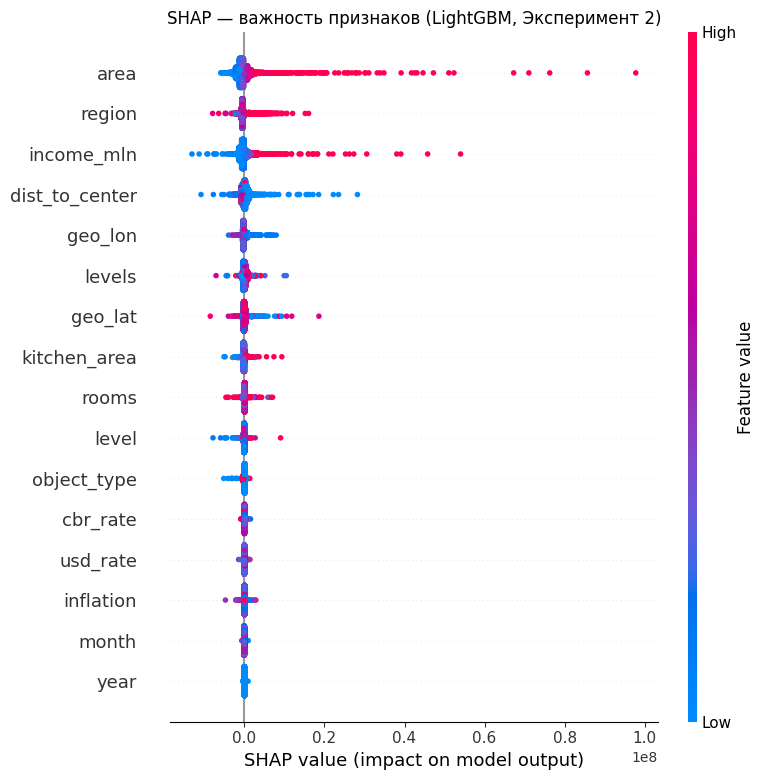

In [33]:
shap_sample = X_test.sample(5000, random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES_MACRO, show=False)
plt.title('SHAP — важность признаков (LightGBM, Эксперимент 2)')
plt.tight_layout()
plt.show()

## 14. Анализ влияния макропризнаков

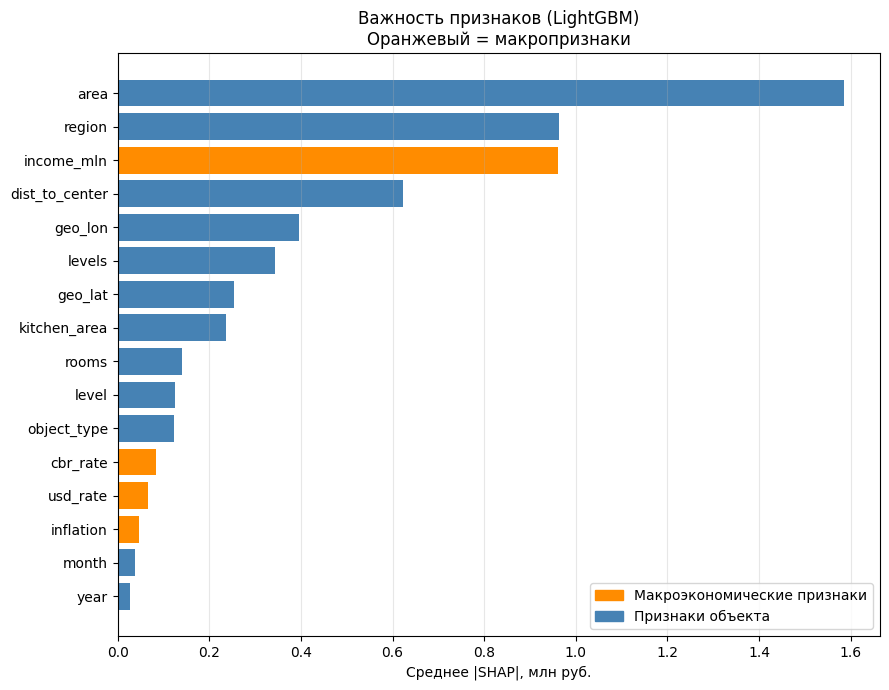


Макропризнаки:
   feature  mean_abs_shap
income_mln         0.9603
  cbr_rate         0.0825
  usd_rate         0.0661
 inflation         0.0473


In [34]:
# Средний абсолютный SHAP по каждому признаку
shap_abs_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEATURES_MACRO, 'mean_abs_shap': shap_abs_mean})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=True)

# Выделяем макропризнаки цветом
macro_features = {'cbr_rate', 'inflation', 'usd_rate', 'income_mln'}
colors = ['darkorange' if f in macro_features else 'steelblue' for f in shap_df['feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df['feature'], shap_df['mean_abs_shap'] / 1e6, color=colors)
ax.set_xlabel('Среднее |SHAP|, млн руб.')
ax.set_title('Важность признаков (LightGBM)\nОранжевый = макропризнаки')
ax.grid(axis='x', alpha=0.3)

import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='darkorange', label='Макроэкономические признаки'),
    mpatches.Patch(color='steelblue',  label='Признаки объекта'),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

print('\nМакропризнаки:')
print(shap_df[shap_df['feature'].isin(macro_features)][['feature', 'mean_abs_shap']]
      .sort_values('mean_abs_shap', ascending=False)
      .assign(mean_abs_shap=lambda x: (x['mean_abs_shap'] / 1e6).round(4))
      .to_string(index=False))